# Exploring the Amazon Fashion metadata

A guided look at the catalog behind the recommendation service: 826,108 product
listings. Written so that a non-engineer can follow it. Every section starts with
the question in plain words, shows a chart or a table, and ends with the decision
the answer forced.

Two parts:

1. **First look** (sections 1 to 5): what i checked before writing any code. Which
   fields exist, whether popular products are documented better, which search model
   to use, and what the LLM does with a human sentence.
2. **The catalog under the microscope** (sections 6 to 12): written while building.
   Prices, ratings, duplicate listings, brands, and the measured evidence behind the
   biggest calls: hybrid search, the popular-first demo index, and serving the full
   catalog.

Run from the repo root after `make data ingest index` (sections 2, 3 and 9 also read
the ingest stats and the quick 100K index those targets produce; section 10 reads the
committed `docs/eval_*.json`). Section 5 needs an LLM key; every other cell runs
offline.

In [1]:
import gzip, json, re, itertools, collections, time, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
# work from the repo root whether this runs from notebooks/ or the root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
import os; os.chdir(ROOT); sys.path.insert(0, str(ROOT / "src"))
from stylist.catalog import parse_price, derive_audience, group_key

RAW = Path("data/raw/meta_Amazon_Fashion.jsonl.gz")
assert RAW.exists(), "run `make data` first"

# one small chart style used everywhere: quiet grid, no box, direct labels.
# palette: colorblind-checked categorical order (blue, orange, aqua, yellow, magenta)
PAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "font.size": 10,
})

def tidy(ax, ygrid=True):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    if ygrid:
        ax.grid(axis="y", color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)

def fmt_count(n):
    return f"{n/1e3:.0f}K" if n >= 10_000 else f"{n:,.0f}"

from matplotlib.ticker import FuncFormatter
KTICKS = FuncFormatter(lambda v, _: fmt_count(v) if v else "0")

## Part 1: first look, before any code was written

Day one. The point of these five checks was to find out what the data would allow
at all, and they ended up deciding most of the architecture.

## 1. Which fields can we actually count on?

The assignment lists 14 fields per product. How many of them are actually filled
in? A search feature can only use fields that exist.

The cell below streams the whole file once (826K rows, about a minute) and counts
what is non-empty.

In [2]:
keys = collections.Counter(); nonempty = collections.Counter(); n = 0
rating_number = []; title_len = []; dept = collections.Counter(); cat_depth = collections.Counter()
prices = []; years = collections.Counter()
with gzip.open(RAW, "rt") as f:
    for line in f:
        r = json.loads(line); n += 1
        for k, v in r.items():
            keys[k] += 1
            if v not in (None, "", [], {}): nonempty[k] += 1
        rating_number.append(r.get("rating_number") or 0)
        title_len.append(len(r.get("title") or ""))
        cat_depth[len(r.get("categories") or [])] += 1
        d = r.get("details") or {}
        if "Department" in d: dept[d["Department"].strip().lower()] += 1
        p, status = parse_price(r.get("price"))
        if p is not None: prices.append(p)
        m = re.search(r"(\d{4})", d.get("Date First Available", ""))
        if m: years[m.group(1)] += 1
print("rows:", n)
cov = pd.Series({k: nonempty[k] / n for k in keys}).sort_values(ascending=False)
cov.round(3).to_frame("non-empty share")

rows: 826108


,non-empty share
main_category,1.000
average_rating,1.000
rating_number,1.000
parent_asin,1.000
images,1.000
title,1.000
details,0.968
store,0.968
features,0.561
description,0.072


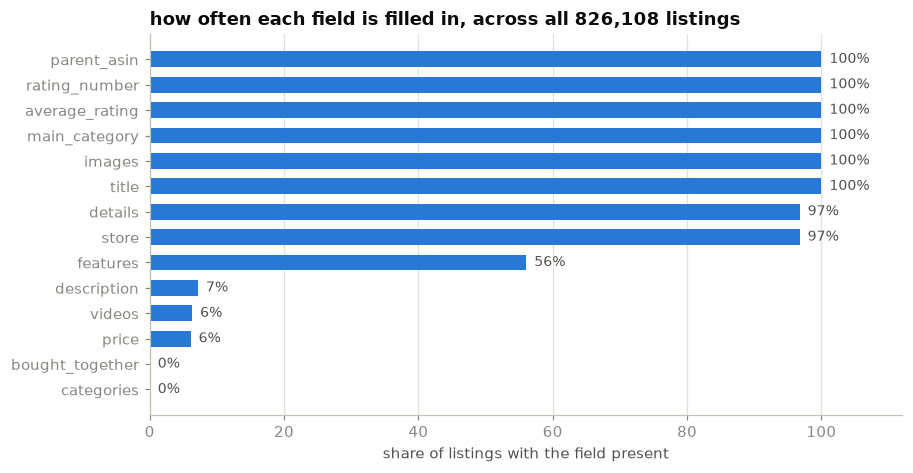

In [3]:
share = (cov * 100)
fig, ax = plt.subplots(figsize=(8.4, 4.4))
vals = share.sort_values()
colors = [MUTED if v == 0 else PAL[0] for v in vals]
bars = ax.barh(vals.index, vals.values, color=colors, height=0.62)
for b, v in zip(bars, vals.values):
    ax.text(v + 1.2, b.get_y() + b.get_height() / 2, f"{v:.0f}%" if v >= 1 else ("0%" if v == 0 else f"{v:.1f}%"),
            va="center", fontsize=9, color=INK2)
ax.set_xlim(0, 112)
ax.set_title("how often each field is filled in, across all 826,108 listings")
ax.set_xlabel("share of listings with the field present")
tidy(ax, ygrid=False)
ax.grid(axis="x", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

*Read it top-down: title, images and ratings are always there. Everything below
`features` is scarce, and the two fields at the bottom are empty on every single
row.*

So: `categories` (a product taxonomy) is empty for all 826,108 rows, and
`bought_together` (bundle suggestions) is always null. That killed two ideas on
day one: no category tree to filter by, no "people also bought". A price exists on
6% of listings, a description on 7%.

The one text field you can count on everywhere is the title. Sellers pack brand,
audience, product type, colour and size into that single line; the median title
runs 89 characters.

**The decision this forced: the title carries the search, everything else is a
bonus.** Both search channels (meaning-based and keyword-based) index the title
plus whatever features and details a row happens to have.

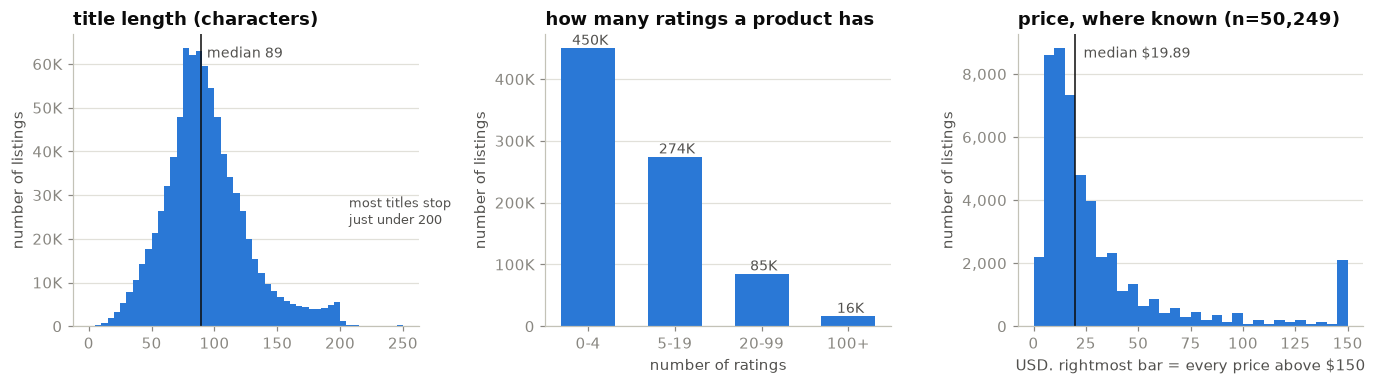

ratings: median 4.0 | products with zero ratings: 0 | 5+: 375,906 | 20+: 101,508 | 100+: 16,483
titles 190-200 chars: 11,351 | longer than 200: 1,680 (the pile-up under 200 looks like a source cap)
price: p90 $71.91 | max $13,000 | share of known prices under $20: 53%
categories depth: {0: 826108}


In [4]:
rn = np.array(rating_number)
fig, ax = plt.subplots(1, 3, figsize=(12.6, 3.6))

ax[0].hist(np.clip(title_len, 0, 250), bins=50, color=PAL[0])
ax[0].set_title("title length (characters)")
ax[0].set_ylabel("number of listings")
ax[0].yaxis.set_major_formatter(KTICKS)
ax[0].axvline(np.median(title_len), color=INK, linewidth=1)
ax[0].text(np.median(title_len) + 5, ax[0].get_ylim()[1] * 0.92, f"median {np.median(title_len):.0f}", fontsize=9, color=INK2)
ax[0].text(207, ax[0].get_ylim()[1] * 0.35, "most titles stop\njust under 200", fontsize=8.5, color=INK2)

buckets = {"0-4": (rn <= 4).sum(), "5-19": ((rn >= 5) & (rn <= 19)).sum(),
           "20-99": ((rn >= 20) & (rn <= 99)).sum(), "100+": (rn >= 100).sum()}
bars = ax[1].bar(buckets.keys(), buckets.values(), color=PAL[0], width=0.62)
for b, v in zip(bars, buckets.values()):
    ax[1].text(b.get_x() + b.get_width() / 2, v, f" {fmt_count(v)}", ha="center", va="bottom", fontsize=9, color=INK2)
ax[1].set_title("how many ratings a product has")
ax[1].set_xlabel("number of ratings")
ax[1].set_ylabel("number of listings")
ax[1].yaxis.set_major_formatter(KTICKS)

p = np.array(prices)
clipped = np.clip(p, 0, 150)
ax[2].hist(clipped, bins=30, color=PAL[0])
ax[2].set_title(f"price, where known (n={len(p):,})")
ax[2].set_xlabel("USD. rightmost bar = every price above $150")
ax[2].set_ylabel("number of listings")
ax[2].yaxis.set_major_formatter(KTICKS)
ax[2].axvline(np.median(p), color=INK, linewidth=1)
ax[2].text(np.median(p) + 4, ax[2].get_ylim()[1] * 0.92, f"median ${np.median(p):.2f}", fontsize=9, color=INK2)

for a in ax:
    tidy(a)
plt.tight_layout(); plt.show()
tl = np.array(title_len)
print("ratings: median", np.median(rn), "| products with zero ratings:", (rn == 0).sum(),
      "| 5+:", f"{(rn>=5).sum():,}", "| 20+:", f"{(rn>=20).sum():,}", "| 100+:", f"{(rn>=100).sum():,}")
print("titles 190-200 chars:", f"{((tl>=190)&(tl<=200)).sum():,}", "| longer than 200:",
      f"{(tl>200).sum():,} (the pile-up under 200 looks like a source cap)")
print("price: p90", f"${np.percentile(p, 90):.2f}", "| max", f"${p.max():,.0f}",
      "| share of known prices under $20:", f"{(p < 20).mean():.0%}")
print("categories depth:", dict(cat_depth))

*Three shapes worth knowing. Titles are long and pile up just under 200
characters, which looks like a cap at the source. Ratings are extremely lopsided:
over half of all products have four ratings or fewer, while a tiny group has
thousands. Known prices sit mostly under $40 (median $19.89), with a long
expensive tail up to $13,000.*

That middle chart matters most. "Popular" here means "has many ratings", and only
16,483 products out of 826,108 pass the 100-ratings bar. Keep that shape in mind
for the next section.

## 2. Does popularity buy better metadata?

The plain question: are well-rated products also better documented? If yes, a demo
index built from popular products gets richer data to filter and explain with.

The ingest step records field coverage per rating bucket
(`data/processed/ingest_stats.json`, written by `make ingest`). Drawn below.

,price,features,description,department,material,rows
rating_number bucket,,,,,,
0-4,0.0485,0.5026,0.0617,0.1168,0.0181,450202.0
5-19,0.0529,0.6051,0.0615,0.1379,0.0300,274398.0
20-99,0.1127,0.6785,0.1227,0.2482,0.0575,85025.0
100-inf,0.2638,0.7926,0.2546,0.4914,0.0867,16483.0


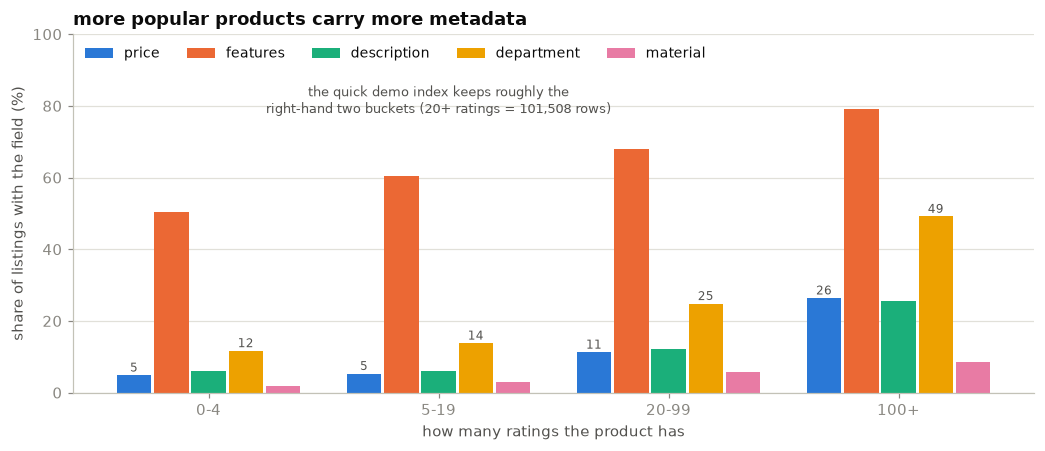

In [5]:
stats = json.loads(Path("data/processed/ingest_stats.json").read_text())
by_bucket = pd.DataFrame(stats["by_rating_bucket"]).T
by_bucket.index.name = "rating_number bucket"
# image_url is 100% in every bucket (section 1), so it would only flatten the chart
display(by_bucket.drop(columns=["image_url"]))

fields = ["price", "features", "description", "department", "material"]
labels = {"0-4": "0-4", "5-19": "5-19", "20-99": "20-99", "100-inf": "100+"}
x = np.arange(len(by_bucket))
w = 0.15
fig, ax = plt.subplots(figsize=(9.6, 4.2))
for i, f in enumerate(fields):
    vals = by_bucket[f].values * 100
    bars = ax.bar(x + (i - 2) * (w + 0.012), vals, width=w, color=PAL[i], label=f)
    if f in ("price", "department"):
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f}", ha="center", fontsize=8, color=INK2)
ax.set_xticks(x, [labels[i] for i in by_bucket.index])
ax.set_xlabel("how many ratings the product has")
ax.set_ylabel("share of listings with the field (%)")
ax.set_title("more popular products carry more metadata")
ax.legend(frameon=False, ncols=5, loc="upper left", fontsize=9)
ax.set_ylim(0, 100)
tidy(ax)
ax.annotate("the quick demo index keeps roughly the\nright-hand two buckets (20+ ratings = 101,508 rows)",
            xy=(1.0, 78), fontsize=8.5, color=INK2, ha="center")
plt.tight_layout(); plt.show()

*Read any one colour left to right: it climbs. A product with 100+ ratings has a
price 26% of the time; a product with 0-4 ratings, 4.9%. Features go 50% to 79%,
department 12% to 49%. (Description is the exception early on: flat at 6% until
20 ratings, climbing only after.)*

Popular listings are simply better documented. That matters twice over: the price
filter can only act on rows that have a price, and the model explaining a pick can
only cite fields that exist.

**What this settled on day one: a quick index of the top 100,000 listings by
rating count.** (Everything with 20 or more ratings is 101,508 rows, so the
boundary falls inside the 20-rating group and the last 1,508 of that tie miss
the cut.) It builds in 3 minutes, serves in 1 GB of memory, and its rows carry
the best metadata. The trade-off, losing the long tail, is not hidden: every API
response names the subset it answered from, and section 10 measures exactly what
the subset costs against the full catalog, which is what the deployed service
ended up serving.

## 3. Who is each product for, and which listings are twins?

No taxonomy means no "department: women" filter for most rows. So the audience
(women / men / girls / boys / baby / unisex) is guessed: from `details.Department`
when present, from title words otherwise. The same title also yields a grouping
key that collapses size and colour variants of one product at query time.

First, how the guessed audience splits across the whole catalog:

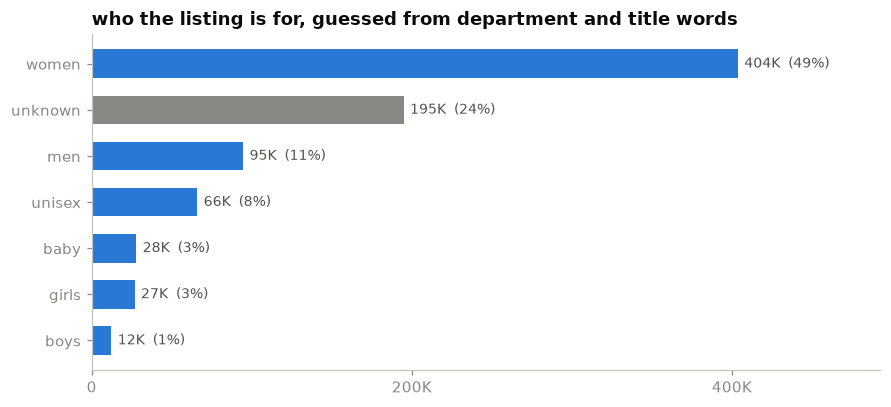

          listings  share
audience                 
women       403722  0.489
unknown     194903  0.236
men          94614  0.115
unisex       65966  0.080
baby         27833  0.034
girls        26796  0.032
boys         12274  0.015

note: 'unknown' is treated as a wildcard. an audience filter keeps unknown rows in, so a thin guess never hides a product.


title-vs-department check on the 116,972 rows where the department names an audience:
the title alone reaches a verdict on 64% of them, and that verdict matches the department 78% of the time


In [6]:
aud = pd.read_parquet("data/processed/catalog.parquet", columns=["audience"])["audience"]
counts = aud.value_counts()
order = counts.sort_values()
fig, ax = plt.subplots(figsize=(8.2, 3.8))
colors = [MUTED if k == "unknown" else PAL[0] for k in order.index]
bars = ax.barh(order.index, order.values, color=colors, height=0.62)
for b, v in zip(bars, order.values):
    ax.text(v + 4000, b.get_y() + b.get_height() / 2, f"{fmt_count(v)}  ({v/len(aud):.0%})",
            va="center", fontsize=9, color=INK2)
ax.set_title("who the listing is for, guessed from department and title words")
ax.set_xlim(0, order.max() * 1.22)
ax.set_xticks([0, 200_000, 400_000], ["0", "200K", "400K"])
tidy(ax, ygrid=False)
plt.tight_layout(); plt.show()
print(pd.DataFrame({"listings": counts, "share": (counts / len(aud)).round(3)}).to_string())
print()
print("note: 'unknown' is treated as a wildcard. an audience filter keeps unknown",
      "rows in, so a thin guess never hides a product.")
# a harder check of the title heuristic: on rows where the department field names an
# audience, does a title-only guess agree with it?
sub = pd.read_parquet("data/processed/catalog.parquet", columns=["title", "department"])
dept_aud = sub["department"].map(lambda d: derive_audience("", d if isinstance(d, str) else None))
named = dept_aud != "unknown"
title_aud = sub.loc[named, "title"].map(lambda t: derive_audience(t, None))
decided = title_aud != "unknown"
agree = (title_aud[decided] == dept_aud[named][decided]).mean()
print(f"title-vs-department check on the {named.sum():,} rows where the department names an "
      f"audience:\nthe title alone reaches a verdict on {decided.mean():.0%} of them, and that "
      f"verdict matches the department {agree:.0%} of the time")

*Half the catalog is women's fashion. A quarter cannot be guessed at all, and
those rows stay eligible for every search (filtering them out would silently
shrink the catalog by 195K rows).*

A small data-quality aside that justifies guessing from two sources: the raw
`Department` field is a mess of near-duplicates ("Womens", "womens", "Women",
"Unisex-adult", "unisex-adult"...), and it exists on only 14.5% of rows anyway.

Below, the two heuristics on a spot check of real titles: 25 rows spaced through
the first 300K, enough to catch obvious nonsense, not a validation (the printed
check above is the harder test for the audience guess). `group_key` is the
variant key: same product in another size or colour should map to the same key.

In [7]:
sample = []
with gzip.open(RAW, "rt") as f:
    for line in itertools.islice(f, 0, 300000, 12000):
        sample.append(json.loads(line))
rows = [{"audience": derive_audience(r["title"], (r.get("details") or {}).get("Department")),
         "group_key": group_key(r["title"])[:60], "title": r["title"][:70]} for r in sample]
pd.DataFrame(rows).head(25)

,audience,group_key,title
0,men,yuedge 5 pairs men's moisture control cushione...,YUEDGE 5 Pairs Men's Moisture Control Cushione...
1,men,mountain hardwear men's ratio down vest,Mountain Hardwear Men's Ratio Down Vest (Hardw...
2,women,peacameo women's summer casual tank tops scoop...,Peacameo Women's Summer Casual Tank Tops Scoop...
3,women,manzhen gold dolphin whale tail wrap ring mini...,MANZHEN Gold Dolphin Whale Tail Wrap Ring Mini...
4,unisex,dwwq glory to ukraine slava ukraini caps for m...,DWWQ Glory to Ukraine Slava Ukraini caps for M...
5,men,gsg mens rivet leather belts stylish studded b...,GSG Mens Rivet Leather Belts Stylish Studded B...
6,women,timeson tunic tops for leggings for women shor...,Timeson Tunic Tops For Leggings For Women Shor...
7,unknown,selectees wome graphic v-neck t shirts black l...,SELECTEES Wome Graphic V-Neck T Shirts Black L...
8,women,okdeals charm butterfly necklace crystal drop ...,Okdeals Charm Butterfly Necklace Crystal Drop ...
9,women,myhalf tie dye crop top pullover women long sl...,MYHALF Tie Dye Crop Top Pullover Women Long Sl...


## 4. Which search model reads sentences best?

Two ways to search text. Keyword search (BM25) matches the words you typed.
Embedding search turns text into a list of numbers so that similar meanings land
close together, which lets "outfit for the beach" find a swimsuit that never says
"outfit". The question: which local embedding model is good enough, and does
keyword search still add anything?

The test: the first 40K listings with 5+ ratings in file order (a convenience
sample, not a random one), 8 queries written the way a person would type them,
three small embedding models against BM25, judged by manual inspection of the
top 3 for each. Takes about 2 minutes on a laptop GPU.

In [8]:
from sentence_transformers import SentenceTransformer
import bm25s
from stylist.catalog import build_doc_text

docs, titles = [], []
with gzip.open(RAW, "rt") as f:
    for line in f:
        r = json.loads(line)
        if (r.get("rating_number") or 0) < 5: continue
        docs.append(build_doc_text(r)); titles.append(r["title"][:80])
        if len(docs) >= 40000: break
queries = ["I need an outfit to go to the beach this summer", "warm waterproof boots for hiking in snow",
           "elegant black dress for a wedding guest", "men's slim fit chinos for the office",
           "cozy oversized sweater for fall", "running shoes with good arch support for flat feet",
           "something to keep my ears warm in winter", "comfortable sandals for walking around europe"]

bm = bm25s.BM25(); bm.index(bm25s.tokenize(docs, stopwords="en", show_progress=False), show_progress=False)
results = {"bm25": []}
for q in queries:
    sc = bm.get_scores(bm25s.tokenize([q], stopwords="en", return_ids=False, show_progress=False)[0])
    results["bm25"].append([titles[i] for i in np.argsort(-sc)[:3]])

models = {"bge-small-en-v1.5": ("BAAI/bge-small-en-v1.5", "Represent this sentence for searching relevant passages: "),
          "all-MiniLM-L6-v2": ("sentence-transformers/all-MiniLM-L6-v2", ""),
          "arctic-embed-xs": ("Snowflake/snowflake-arctic-embed-xs", "Represent this sentence for searching relevant passages: ")}
speed = {}
for name, (path, prefix) in models.items():
    m = SentenceTransformer(path)
    t = time.time(); E = m.encode(docs, batch_size=128, normalize_embeddings=True, show_progress_bar=False); speed[name] = len(docs) / (time.time() - t)
    Q = m.encode([prefix + q for q in queries], normalize_embeddings=True)
    S = Q @ E.T
    results[name] = [[titles[i] for i in np.argsort(-S[qi])[:3]] for qi in range(len(queries))]
print({k: f"{v:.0f} docs/s" for k, v in speed.items()})
for qi, q in enumerate(queries):
    print("\n###", q)
    for name in results:
        print(f"  {name:18s}", " | ".join(t[:45] for t in results[name][qi]))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

{'bge-small-en-v1.5': '791 docs/s', 'all-MiniLM-L6-v2': '1313 docs/s', 'arctic-embed-xs': '1467 docs/s'}

### I need an outfit to go to the beach this summer
  bm25               Toddler Girl Summer Tulle Dress Cotton Casual | Kerr's Choice Pink Kitty Bag for Girls | Pink | Go Little One Go Anti-Slip Bamboo Baby Crawli
  bge-small-en-v1.5  Womens Summer Fashion Beach Boho Loose Fit Ca | Summer Beach Dresses for Women Tshirt Sundres | POPYOUNG Women's 2022 Summer Casual Tshirt Dr
  all-MiniLM-L6-v2   Fashion Bikini Swimwear Swimsuit Dress for Wo | Summer Beach Dresses for Women Tshirt Sundres | Summer Casual Tshirt Dresses for Women Swing 
  arctic-embed-xs    Women Summer Beach Boho Cute Pocket Casual Ts | Summer Beach Maxi Dresses for Women Off The S | POPYOUNG Women's 2023 Summer Casual Tshirt Dr

### warm waterproof boots for hiking in snow
  bm25               Mishansha Women's Duck Boots Cold weather Sli | Mens Insulated Waterproof Hiking Snow Boots W | PENGCHENG Men's Snow Boots 

What i took from this:

* bm25 alone is hopeless for "outfit for the beach" (it matches *outfit* and *summer* in toddler listings) and for "keep my ears warm", but it is great at exact phrases like "wedding guest".
* bge-small gives the most sensible lists of the three, at the encoding rate printed above (about 750 docs a second on this laptop, fast enough to index the whole catalog in under 20 minutes). arctic-xs encodes faster and lands close behind on quality; MiniLM reads noticeably weaker on these eight queries.
* audience leaks through on both channels: the dense list put a women's office suit at rank 3 for "men's chinos", and the keyword list for the same query is mostly women's items too. So the service excludes rows labeled for another audience before ranking (rows with no guessable audience stay in), rather than hoping similarity respects gender.

| model | verdict on these 8 queries |
|---|---|
| bge-small-en-v1.5 | best lists, the default |
| arctic-embed-xs | fastest to encode, close second |
| all-MiniLM-L6-v2 | noticeably weaker |
| bm25 (keywords) | fails sentences, wins brands and exact phrases |

**The decision: use both.** Embeddings read the sentence, BM25 catches brands and
exact phrases, and their rankings merge (reciprocal rank fusion). Eight queries
and a manual read are enough to pick a default, not to rank models properly;
section 10's rule-based harness is the sturdier version of this check.

## 5. What the planner does with human queries

The planner is the LLM call that turns the shopper's sentence into a shopping
list: named slots (the outfit pieces to fill: swimsuit, sandals, hat), a search
query per slot, and the constraints (who it is for, the budget, the season).

Needs an LLM key in the environment (`LLM_PROVIDER`, see `.env.example`), so this
cell is tagged `skip-execution` and keeps the output of its original run with
`claude-sonnet-4-6` (the model named in the output below).

In [7]:
from stylist.config import Settings
from stylist.llm import make_llm_client
from stylist.planner import LLMPlanner

settings = Settings.from_env()
llm = make_llm_client(settings)
if llm is None:
    print("no LLM configured, skipping")
else:
    print("model:", llm.model)
    planner = LLMPlanner(llm)
    for q in ["I need an outfit to go to the beach this summer",
              "what should my husband wear to an outdoor wedding in june, budget 200 total",
              "chaussures de running pas cheres pour femme"]:
        plan = await planner.plan(q, timeout=60)
        print("\n###", q)
        print("  intent:", plan.intent, "| audience:", plan.audience, "| budget:", plan.budget_max, plan.budget_scope)
        for s in plan.slots:
            print(f"  - {s.name:14s} q={s.search_query!r}  kw={s.keywords}  budget={s.budget_max}")

model: claude-sonnet-4-6



### I need an outfit to go to the beach this summer
  intent: Complete beach outfit for summer | audience: None | budget: None unknown
  - swimsuit       q="women's summer beach swimsuit one piece or bikini"  kw=['swimsuit', 'bikini', 'one piece', 'swimwear', 'bathing suit']  budget=None
  - cover-up       q="women's beach cover up dress summer lightweight"  kw=['cover up', 'coverup', 'cover-up', 'sarong', 'kaftan']  budget=None
  - sandals        q="women's beach sandals summer flat"  kw=['sandals', 'sandal', 'flip flops', 'slides', 'thongs']  budget=None
  - sun hat        q="women's summer beach sun hat wide brim"  kw=['sun hat', 'beach hat', 'straw hat', 'wide brim hat']  budget=None
  - beach bag      q="women's large beach tote bag summer"  kw=['beach bag', 'tote', 'beach tote', 'straw bag']  budget=None



### what should my husband wear to an outdoor wedding in june, budget 200 total
  intent: Outfit for a man attending an outdoor wedding in June, total budget $200 | audience: men | budget: 200.0 total
  - suit / dress pants q="men's lightweight summer dress trousers wedding"  kw=['dress pants', 'trousers', 'chinos', 'slacks']  budget=54.62
  - dress shirt    q="men's lightweight dress shirt summer wedding"  kw=['dress shirt', 'button down', 'button up', 'oxford shirt']  budget=35.38
  - blazer         q="men's lightweight summer blazer wedding outdoor"  kw=['blazer', 'sport coat', 'suit jacket']  budget=46.92
  - dress shoes    q="men's leather oxford loafer dress shoes wedding"  kw=['oxford', 'loafer', 'derby', 'dress shoes']  budget=43.08
  - tie / pocket square q="men's wedding tie pocket square set summer"  kw=['tie', 'necktie', 'pocket square', 'bow tie']  budget=20.0



### chaussures de running pas cheres pour femme
  intent: Find affordable women's running shoes | audience: women | budget: None unknown
  - running shoes  q="women's running shoes affordable"  kw=['running shoes', 'running sneakers', 'trainers', 'athletic shoes']  budget=None


The planner translates the french query, splits the outfit into pieces and
allocates a total budget across slots (shoes get more than the tie). Those
per-slot queries are what the retriever actually searches, the shopper's sentence
never hits the index directly.

One bias worth naming: for the beach query the planner wrote "women's" into every
slot query even though the shopper never said so (the structured audience field
correctly stayed null). A silent default like that tilts results. The request's
audience field overrides it, but the honest note is that today's evaluation only
scores product type, so this kind of drift needs its own check.

## Part 2: the catalog under the microscope

Written while building the service, after part 1 had fixed the architecture. Each
section here is the evidence behind one production decision: how prices behave,
how ratings should be trusted, how many listings are twins, where the brands
live, and what the measured quality numbers say about serving 100K rows versus
all 826,108.

In [9]:
cat = pd.read_parquet("data/processed/catalog.parquet",
                      columns=["title", "price", "average_rating", "rating_number",
                               "audience", "store", "brand", "department"])
print(f"loaded {len(cat):,} rows,", f"{cat['price'].notna().sum():,} with a known price",
      f"({cat['price'].notna().mean():.1%})")

loaded 826,108 rows, 50,249 with a known price (6.1%)


## 6. Prices: mostly missing, and honest about it

The plain question: can the service promise "under $80"? Only for rows that have
a price at all, and 94% do not. This section shows what the known prices look
like and how unevenly they are spread.

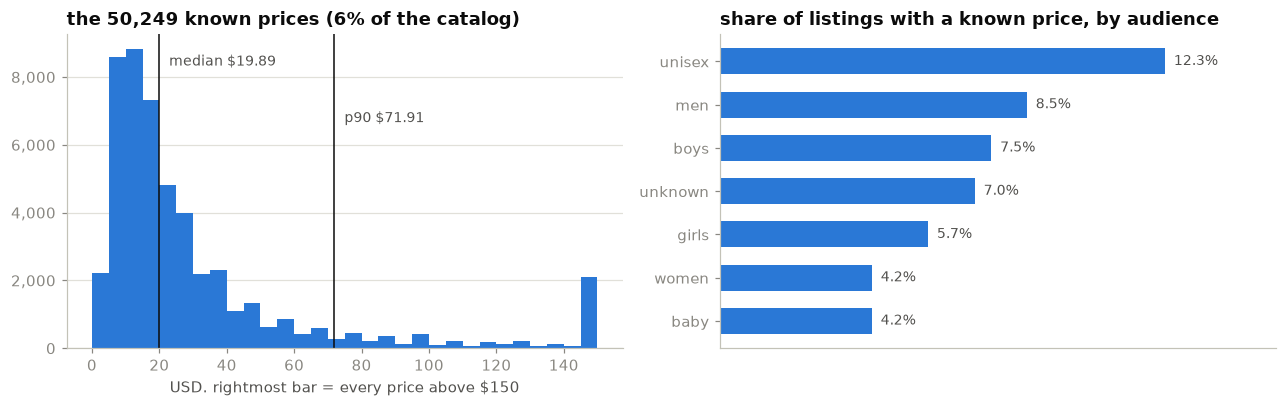

of the known prices: 53% under $20, 80% under $40, max $13,000
known-price share by audience (%):
audience
baby        4.2
women       4.2
girls       5.7
unknown     7.0
boys        7.5
men         8.5
unisex     12.3


In [10]:
known = cat["price"].dropna()
fig, ax = plt.subplots(1, 2, figsize=(11.8, 3.8))

ax[0].hist(np.clip(known, 0, 150), bins=30, color=PAL[0])
ax[0].set_title(f"the {len(known):,} known prices (6% of the catalog)")
ax[0].yaxis.set_major_formatter(KTICKS)
ax[0].set_xlabel("USD. rightmost bar = every price above $150")
for q, name in ((known.median(), "median"), (known.quantile(0.9), "p90")):
    ax[0].axvline(q, color=INK, linewidth=1)
    ax[0].text(q + 3, ax[0].get_ylim()[1] * (0.9 if name == "median" else 0.72),
               f"{name} ${q:.2f}", fontsize=9, color=INK2)

byaud = (cat.groupby("audience")["price"].apply(lambda s: s.notna().mean()) * 100).sort_values()
bars = ax[1].barh(byaud.index, byaud.values, color=PAL[0], height=0.6)
for b, v in zip(bars, byaud.values):
    ax[1].text(v + 0.25, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", fontsize=9, color=INK2)
ax[1].set_title("share of listings with a known price, by audience")
ax[1].set_xlim(0, byaud.max() * 1.25)
ax[1].set_xticks([])
for a in ax:
    tidy(a, ygrid=(a is ax[0]))
plt.tight_layout(); plt.show()
print(f"of the known prices: {(known < 20).mean():.0%} under $20,",
      f"{(known < 40).mean():.0%} under $40, max ${known.max():,.0f}")
print("known-price share by audience (%):")
print(byaud.round(1).to_string())

*Left: known prices cluster under $40. Right: coverage is uneven, women's
listings carry a price only 4.2% of the time, unisex 12.3%.*

**The decision this forced (after a real failure):** the first version filtered
every budget query to priced rows only. For "outdoor wedding, budget $200 total"
the blazer slot came back with a $13 wooden ring, because among the few priced
rows there was no blazer at all. Now the rule is split. A price limit you type
explicitly is a promise: only rows with a known price inside it. A budget read
out of your sentence is a hint: unpriced rows may still appear, every item says
`price_known: true/false`, and the answer never claims an unpriced item fits the
budget.

## 7. Ratings: when is 5.0 stars worse than 4.8?

Next worry: should a product with one 5-star rating outrank a product with five
hundred 4.8-star ratings? Star averages on tiny samples are noise, and the left
chart shows how common tiny samples are (half the catalog has 4 ratings or
fewer, section 1).

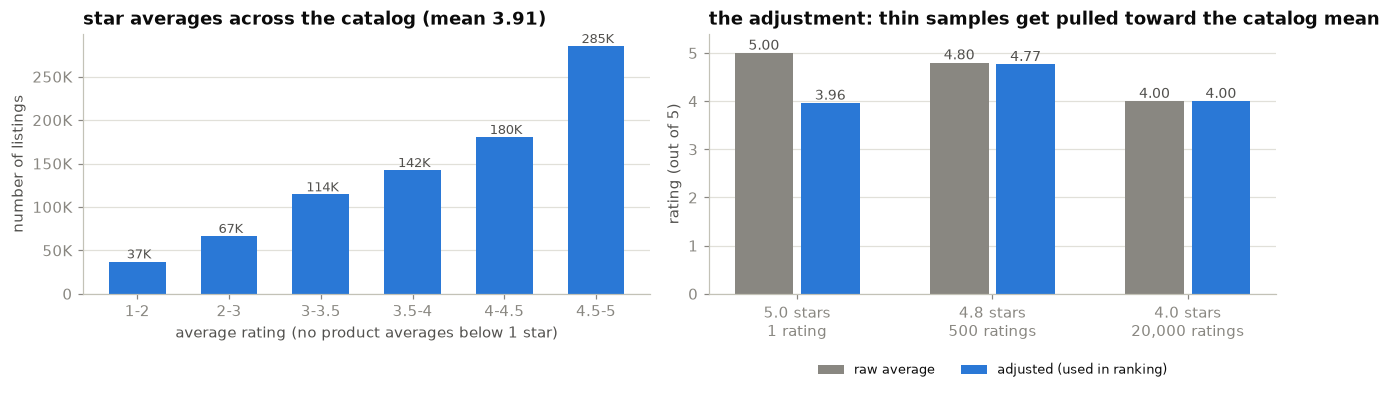

catalog mean rating (the prior): 3.91. the pull is worth 20 pretend ratings.


In [11]:
from stylist.retrieval import bayes_rating

fig, ax = plt.subplots(1, 2, figsize=(11.8, 3.8))
hist_buckets = [(1, 2), (2, 3), (3, 3.5), (3.5, 4), (4, 4.5), (4.5, 5.01)]
names = ["1-2", "2-3", "3-3.5", "3.5-4", "4-4.5", "4.5-5"]
avg = cat["average_rating"].astype(float)
vals = [((avg >= lo) & (avg < hi)).sum() for lo, hi in hist_buckets]
bars = ax[0].bar(names, vals, color=PAL[0], width=0.62)
for b, v in zip(bars, vals):
    ax[0].text(b.get_x() + b.get_width() / 2, v, f" {fmt_count(v)}", ha="center", va="bottom", fontsize=8.5, color=INK2)
ax[0].set_title(f"star averages across the catalog (mean {avg.mean():.2f})")
ax[0].set_xlabel("average rating (no product averages below 1 star)")
ax[0].set_ylabel("number of listings")
ax[0].yaxis.set_major_formatter(KTICKS)

prior = float(avg[cat["rating_number"] > 0].mean())
examples = [("5.0 stars\n1 rating", 5.0, 1), ("4.8 stars\n500 ratings", 4.8, 500),
            ("4.0 stars\n20,000 ratings", 4.0, 20000)]
x = np.arange(len(examples))
raw = [e[1] for e in examples]
adj = [bayes_rating(e[1], e[2], m=20, prior=prior) for e in examples]
b1 = ax[1].bar(x - 0.17, raw, width=0.3, color=MUTED, label="raw average")
b2 = ax[1].bar(x + 0.17, adj, width=0.3, color=PAL[0], label="adjusted (used in ranking)")
for bs in (b1, b2):
    for b in bs:
        ax[1].text(b.get_x() + b.get_width() / 2, b.get_height(), f"{b.get_height():.2f}",
                   ha="center", va="bottom", fontsize=9, color=INK2)
ax[1].set_xticks(x, [e[0] for e in examples])
ax[1].set_ylim(0, 5.4)
ax[1].set_ylabel("rating (out of 5)")
ax[1].set_title("the adjustment: thin samples get pulled toward the catalog mean")
ax[1].legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncols=2)
for a in ax:
    tidy(a)
plt.tight_layout(); plt.show()
print(f"catalog mean rating (the prior): {prior:.2f}. the pull is worth 20 pretend ratings.")

*Right chart, first pair: the lone 5.0 collapses to 3.96 once the adjustment adds
20 pretend ratings at the catalog average. The 4.8 with 500 real ratings barely
moves, and the 4.0 with 20,000 moves by less than the rounding.*

**The decision: ranking uses the adjusted score** (a Bayesian average, in the
code at `stylist/retrieval.py, bayes_rating`). It is a small tie-breaker on top
of text relevance, worth a tenth of a rank point, but it stops one-rating
five-star listings from floating up.

## 8. Twins: one product, many listings

If a search returns five results and three of them are the same shirt in
different colours, is that a useful answer? First, how much of the catalog is
twins.

group_key over 826,108 titles in 12.1s
duplicate copies beyond each title's first listing (case-insensitive): 56,720
variant groups with more than one listing: 83,621, covering 262,880 rows (32% of the catalog)


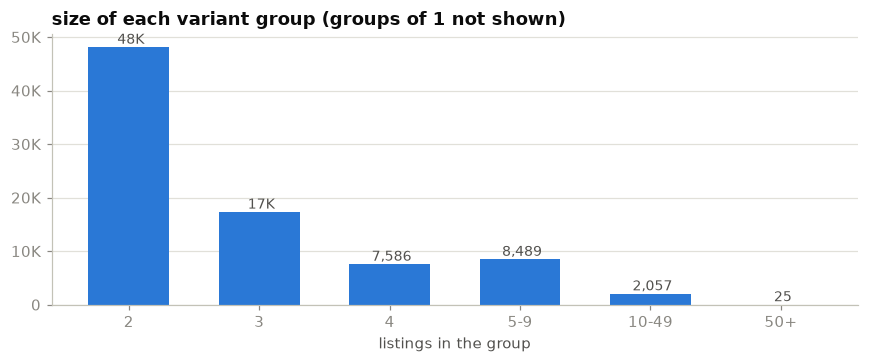

the five biggest groups:
   151 listings ->  marked for archive
   129 listings ->  slevel led light up shoes usb flashing sneakers for kids boys girls
    98 listings ->  dunea women's maxi dress floral printed autumn 3/4 sleeve casual tunic long ma
    93 listings ->  drskin women's open - front long sleeve knit cardigan
    90 listings ->  homeyee women's elegant chic bodycon formal dress b288


In [12]:
t0 = time.time()
gk = cat["title"].map(group_key)
sizes = gk.value_counts()
multi = sizes[sizes > 1]
lower_extra = int(cat["title"].str.lower().duplicated().sum())
print(f"group_key over {len(cat):,} titles in {time.time()-t0:.1f}s")
print(f"duplicate copies beyond each title's first listing (case-insensitive): {lower_extra:,}")
print(f"variant groups with more than one listing: {len(multi):,},",
      f"covering {int(multi.sum()):,} rows ({multi.sum()/len(cat):.0%} of the catalog)")
buckets = {"2": (multi == 2).sum(), "3": (multi == 3).sum(), "4": (multi == 4).sum(),
           "5-9": ((multi >= 5) & (multi <= 9)).sum(), "10-49": ((multi >= 10) & (multi <= 49)).sum(),
           "50+": (multi >= 50).sum()}
fig, ax = plt.subplots(figsize=(8.0, 3.4))
bars = ax.bar(buckets.keys(), buckets.values(), color=PAL[0], width=0.62)
for b, v in zip(bars, buckets.values()):
    ax.text(b.get_x() + b.get_width() / 2, v, f" {fmt_count(v)}", ha="center", va="bottom", fontsize=9, color=INK2)
ax.set_title("size of each variant group (groups of 1 not shown)")
ax.set_xlabel("listings in the group")
ax.yaxis.set_major_formatter(KTICKS)
tidy(ax)
plt.tight_layout(); plt.show()
print("the five biggest groups:")
for k, v in sizes.head(5).items():
    print(f"  {v:4d} listings ->  {k[:78]}")

*The grouping rule places one in three listings in a group with at least one
other row. Most groups are pairs, but the tail is something else: the biggest
"group" is 151 rows literally titled "marked for archive", dead listings that a
naive search would happily return as 151 separate products.*

Two numbers to keep straight: 56,720 listings are duplicate copies beyond some
title's first appearance (comparing titles case-insensitively), and the grouping
rule casts a wider net, 262,880 rows, because it also merges "same shirt, size L,
navy" with "same shirt, size S, red". It is a text heuristic, so that wider
number inherits the rule's mistakes. (Why not group by product id instead? Every
one of the 826,108 rows carries its own `parent_asin`, so the id cannot connect
variants; only the title can.)

**The decision: collapse variants at query time, delete nothing at ingest**
(twin rows can carry different prices and images, and a bug fix in the grouping
rule must not cost a 20-minute index rebuild). One listing per group survives in
a result list, and a group can fill only one slot of an outfit.

## 9. Brands: where the popular subset falls short

The plain question: if a shopper asks for "levi's jeans", does the index even
contain them? The 8 brand queries from the evaluation set, counted in the full
catalog and in the 100K popular subset (the quick 3-minute build).

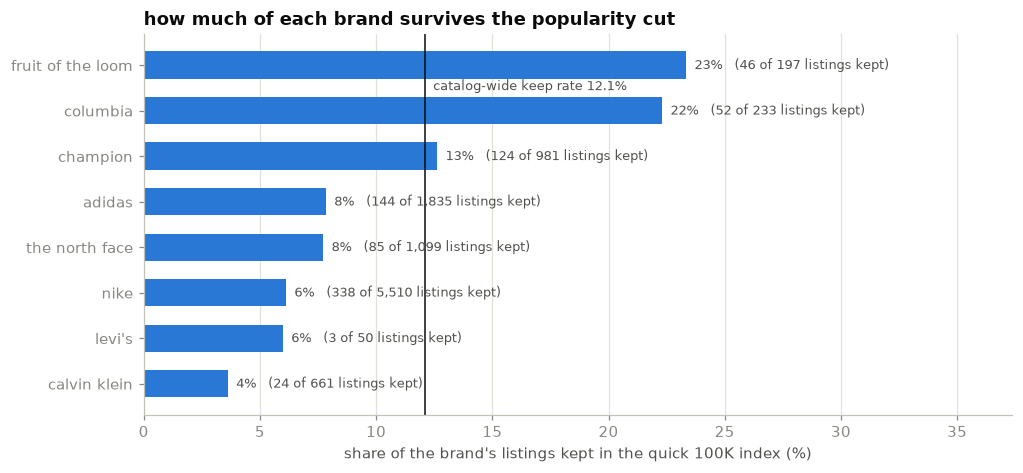

both columns use the same matching rule (the brand as whole words in the title,
store or brand fields); the only difference is which rows each index contains.
nearly gone from the quick index: levi's (3 rows there, 50 in the full catalog)
nearly gone from the quick index: calvin klein (24 rows there, 661 in the full catalog)


In [13]:
idx_cat = pd.read_parquet("data/index/catalog.parquet", columns=["title", "store", "brand"])
assert len(idx_cat) == 100_000, "expected the quick popular-100K index at data/index"

def brand_rows(df, brand):
    pat = re.escape(brand.lower()).replace(r"\ ", r"[\s\-]*").replace("'", "['\u2019]?")
    rx = re.compile(r"\b" + pat + r"\b")
    hay = (df["title"].fillna("") + " | " + df["store"].fillna("") + " | " + df["brand"].fillna("")).str.lower()
    return int(hay.str.contains(rx).sum())

brands = ["nike", "adidas", "the north face", "champion", "fruit of the loom",
          "columbia", "levi's", "calvin klein"]
full_counts = [brand_rows(cat, b) for b in brands]
pop_counts = [brand_rows(idx_cat, b) for b in brands]
keep_rate = [100.0 * p_ / f_ if f_ else 0.0 for f_, p_ in zip(full_counts, pop_counts)]
baseline = 100.0 * len(idx_cat) / len(cat)

order = np.argsort(keep_rate)
y = np.arange(len(brands))
fig, ax = plt.subplots(figsize=(9.4, 4.4))
bars = ax.barh(y, [keep_rate[i] for i in order], color=PAL[0], height=0.6)
for b, i in zip(bars, order):
    ax.text(b.get_width() + 0.35, b.get_y() + b.get_height() / 2,
            f"{keep_rate[i]:.0f}%   ({pop_counts[i]:,} of {full_counts[i]:,} listings kept)",
            va="center", fontsize=8.5, color=INK2)
ax.set_yticks(y, [brands[i] for i in order])
ax.axvline(baseline, color=INK, linewidth=1)
ax.text(baseline + 0.35, len(brands) - 1.55, f"catalog-wide keep rate {baseline:.1f}%",
        fontsize=8.5, color=INK2)
ax.set_title("how much of each brand survives the popularity cut")
ax.set_xlabel("share of the brand's listings kept in the quick 100K index (%)")
ax.set_xlim(0, max(max(keep_rate), baseline) * 1.6)
tidy(ax, ygrid=False)
ax.grid(axis="x", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()
print("both columns use the same matching rule (the brand as whole words in the title,")
print("store or brand fields); the only difference is which rows each index contains.")
for b_, f_, p_ in zip(brands, full_counts, pop_counts):
    if p_ < 25:
        print(f"nearly gone from the quick index: {b_} ({p_} rows there, {f_} in the full catalog)")

*Read it against the marked baseline: the cut keeps 12.1% of the catalog, and
most brands keep less, because brand listings skew toward the thinly-rated long
tail. What saves a brand query is absolute depth: 6% of nike's five thousand
listings still leaves hundreds to answer from; 6% of levi's fifty leaves three.*

This is the concrete cost of the popular-first subset. In the measured
evaluation, "columbia rain jacket" and "levi's jeans" score 0 of 4 on-brand items
on the 100K index and 4 of 4 on the full catalog. The service says so honestly (a
warning names the fallback), but honesty is not the same as having the jeans.

**The decision this supports: serve the full catalog.** The deployed service
does, since brand requests are exactly the queries a shopper notices failing.
The next section prices that decision.

## 10. The measured evidence: what each part of the pipeline buys

The evaluation harness runs 28 human-style queries (20 conversational, 8 brand)
against three indexes and several configurations. The score, called match@4 here
(the json field is `keyword_match_at_k`), is the share of returned items whose
title passes a hand-written product-type rule for its slot: a sandals slot
accepts sandal / flip flop / slide, a jeans slot needs the brand too.

Three honesty rules make the bars comparable. The type rules were written before
looking at any output, so the metric could not be shopped. The two planner
configurations replay the same recorded plans on every index (the no-planner
rows search the raw sentence, which is exactly the difference being measured).
And a slot the planner invents that has no rule is scored against the union of
the query's rules rather than skipped. One more definition the chart needs:
`query success` is the harshest metric, every expected slot came back, none
empty, and every returned slot has at least one passing item.

All of this is a type-correctness floor, deliberately blind to style and taste.
That is also why it is useful: before anyone argues about taste, the system must
at least fetch the right kind of item. Numbers come straight from the committed
result files (`docs/eval_*.json`).

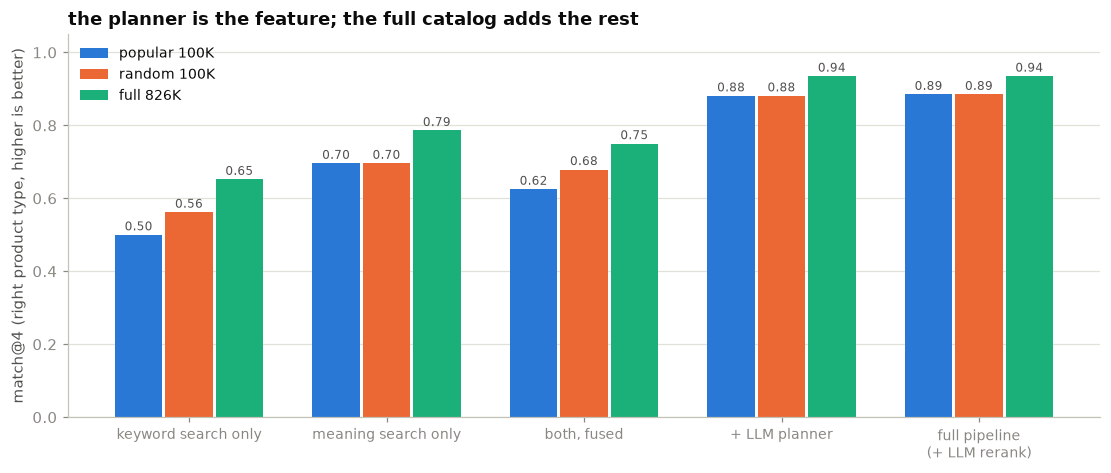

popular 100K full pipeline: match@4 0.885, query success 0.61, empty slots 0, price violations 0
random 100K  full pipeline: match@4 0.885, query success 0.61, empty slots 0, price violations 0
full 826K    full pipeline: match@4 0.935, query success 0.71, empty slots 0, price violations 0

where the full catalog's advantage sits (full pipeline, per query class):
popular 100K conversational 0.925 (20 queries) | brand 0.688 (8 queries)
full 826K    conversational 0.953 (20 queries) | brand 1.000 (8 queries)


In [14]:
files = {"popular 100K": "docs/eval_popular100k.json",
         "random 100K": "docs/eval_random100k.json",
         "full 826K": "docs/eval_full.json"}
show = [("bm25", "keyword search only"), ("dense", "meaning search only"),
        ("hybrid", "both, fused"), ("llm_plan", "+ LLM planner"),
        ("llm_plan_rerank", "full pipeline\n(+ LLM rerank)")]
data = {}
for label, path in files.items():
    d = json.loads(Path(path).read_text())
    rows = {r["config"]: r for r in d["results"]}
    data[label] = [rows[c]["keyword_match_at_k"] for c, _ in show]

x = np.arange(len(show))
w = 0.24
fig, ax = plt.subplots(figsize=(10.2, 4.4))
for i, (label, vals) in enumerate(data.items()):
    bars = ax.bar(x + (i - 1) * (w + 0.015), vals, width=w, color=PAL[i], label=label)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.2f}", ha="center", fontsize=8, color=INK2)
ax.set_xticks(x, [n for _, n in show], fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("match@4 (right product type, higher is better)")
ax.set_title("the planner is the feature; the full catalog adds the rest")
ax.legend(frameon=False, fontsize=9, loc="upper left")
tidy(ax)
plt.tight_layout(); plt.show()
for label, path in files.items():
    d = json.loads(Path(path).read_text())
    r = {x_["config"]: x_ for x_ in d["results"]}["llm_plan_rerank"]
    print(f"{label:12s} full pipeline: match@4 {r['keyword_match_at_k']:.3f},",
          f"query success {r['query_success']:.2f}, empty slots {r['empty_slots']},",
          f"price violations {r['price_violations']}")
print()
print("where the full catalog's advantage sits (full pipeline, per query class):")
for label in ("popular 100K", "full 826K"):
    d = json.loads(Path(files[label]).read_text())
    row = {x_["config"]: x_ for x_ in d["results"]}["llm_plan_rerank"]
    pq = row.get("per_query_match")
    if not isinstance(pq, dict):
        print(f"{label:12s} (no per-query detail in this file)")
        continue
    brand = [v for k, v in pq.items() if k.startswith("brand_")]
    conv = [v for k, v in pq.items() if not k.startswith("brand_")]
    print(f"{label:12s} conversational {sum(conv)/len(conv):.3f} ({len(conv)} queries) |",
          f"brand {sum(brand)/len(brand):.3f} ({len(brand)} queries)")

*Read left to right within one colour: the first three bars search the shopper's
raw sentence through different channels and manage 0.50 to 0.79; the last two
give those channels the planner's rewritten queries instead, the big jump to 0.88
and above (the rerank adds about one more point on top). Read the colours at any
x: the full catalog beats both 100K subsets, and the class split printed below
the chart shows where that advantage sits.*

What the full catalog costs, measured on the same laptop:

| index | rows | build time | memory to serve | retrieval p50 |
|---|---|---|---|---|
| popular 100K | 100,000 | 2.6 min | 1.0 GB | 22 ms |
| full catalog | 826,108 | 18.4 min | 3.3 GB | 110 ms |

(build times from each index's `meta.json`; memory and latency from
`scripts/benchmark.py` runs recorded in `docs/production.md`.)

**The decision: both stay, with different jobs.** The 100K popular index is the
3-minute reviewer build; the full catalog is what the deployed service serves,
at 3.3 GB and a still-comfortable 110 ms of retrieval, because brand and
long-tail coverage are worth that price. Zero empty slots and zero price
violations hold on every index.

## 11. Where the seconds go

Last question: a full answer takes about 11 seconds with a large model. Where
does the time actually go? Timings from the recorded 20-query live run
(`docs/live_run_sonnet.json`, claude-sonnet-4-6).

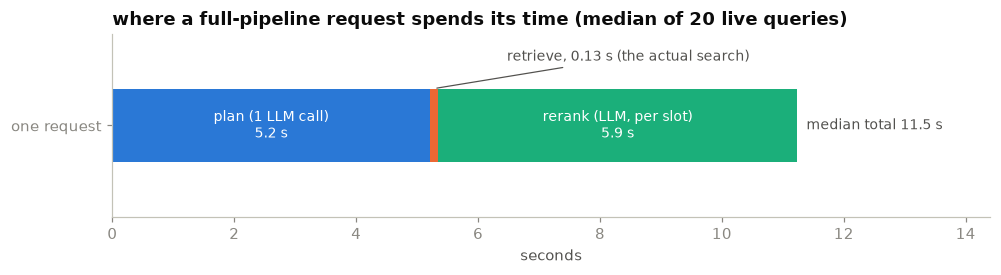

retrieval is 1.1% of the median total; nearly all the rest is the planner call plus the per-slot rerank calls (stage medians shown; they need not sum exactly to the total median)


In [15]:
import statistics
run = json.loads(Path("docs/live_run_sonnet.json").read_text())
rows = run["sequential"]
stages = ["plan_ms", "retrieve_ms", "rerank_ms"]
med = {s: statistics.median(r["timings"][s] for r in rows) / 1000 for s in stages}
total = statistics.median(r["timings"]["total_ms"] for r in rows) / 1000

fig, ax = plt.subplots(figsize=(9.2, 2.6))
left = 0.0
names = {"plan_ms": "plan (1 LLM call)", "retrieve_ms": "retrieve", "rerank_ms": "rerank (LLM, per slot)"}
retrieve_mid = None
for i, s in enumerate(stages):
    ax.barh(["one request"], [med[s]], left=left, color=PAL[i], height=0.5)
    if med[s] > 0.5:
        ax.text(left + med[s] / 2, 0, f"{names[s]}\n{med[s]:.1f} s", ha="center", va="center",
                fontsize=9, color="white")
    else:
        retrieve_mid = left + med[s] / 2
    left += med[s]
ax.text(left + 0.15, 0, f"median total {total:.1f} s", va="center", fontsize=9, color=INK2)
if retrieve_mid is not None:
    ax.annotate(f"retrieve, {med['retrieve_ms']:.2f} s (the actual search)",
                xy=(retrieve_mid, 0.25), xytext=(retrieve_mid + 1.2, 0.44),
                fontsize=9, color=INK2, arrowprops={"arrowstyle": "-", "color": INK2, "lw": 0.8})
ax.set_xlim(0, total * 1.25)
ax.set_ylim(-0.62, 0.62)
ax.set_title("where a full-pipeline request spends its time (median of 20 live queries)")
ax.set_xlabel("seconds")
tidy(ax, ygrid=False)
plt.tight_layout(); plt.show()
print(f"retrieval is {med['retrieve_ms']/total:.1%} of the median total; nearly all the rest is",
      "the planner call plus the per-slot rerank calls",
      "(stage medians shown; they need not sum exactly to the total median)")

*The tiny aqua sliver in the middle is the actual search. Nearly everything else
is model calls: one to plan, then one per slot to rerank.*

**What this drove in the deployed service: move the model out of the hot
path.** A request waits at most 0.1 s for the planner and answers immediately
with a fallback plan; the real plan finishes in the background about a second
later and is cached for everyone after, paraphrases included. Measured from a
client in Japan against the full catalog, cached answers come back in 13 to
45 ms and a cold unique query in about half a second. The full story with every
number lives in `docs/aws-latency.md`.

## 12. What each chart decided

| evidence (section) | decision it forced | where it lives |
|---|---|---|
| taxonomy and bundles empty, title always present (1) | the title carries retrieval | `catalog.py build_doc_text`, ADR-001 |
| metadata quality climbs with popularity (2) | popular-first 100K demo index, bias stated per response | ADR-005 |
| a quarter of rows have no guessable audience (3) | audience filters keep "unknown" rows in | `retrieval.py eligibility_masks` |
| bm25 fails sentences, embeddings leak gender (4) | hybrid search + audience as a hard mask | ADR-002, ADR-003 |
| a sentence is not a search query (5) | the LLM planner rewrites it, with a regex fallback | ADR-006 |
| 94% of prices missing, unevenly (6) | strict explicit bounds, flagged inferred ones, `price_known` | ADR-008 |
| star averages on tiny samples (7) | Bayesian rating adjustment as a tie-breaker | `retrieval.py bayes_rating` |
| a third of the catalog is twins (8) | variant collapse at query time, nothing deleted | ADR-009 |
| brands vanish from the popular subset (9) | serve the full catalog for brand coverage | the deployed service |
| planner + full catalog are the measured wins (10) | 0.885 -> 0.935 match@4 on the same plans | `docs/evaluation.md` |
| 99% of latency is model calls (11) | background planning + caches in the deployed profile | `docs/aws-latency.md` |

In one line: the catalog gives you titles, ratings and images and almost nothing
else, so the system trusts titles, treats everything scarce as a flagged bonus,
and proves each of those calls with a number.